마이크 어레이의 y위치
 [4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9] <class 'numpy.ndarray'>
마이크 어레이의 최종 위치
 [[6.3 6.3 6.3 6.3 6.3 6.3 6.3 6.3 6.3 6.3]
 [4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9]
 [1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2]] <class 'numpy.ndarray'>


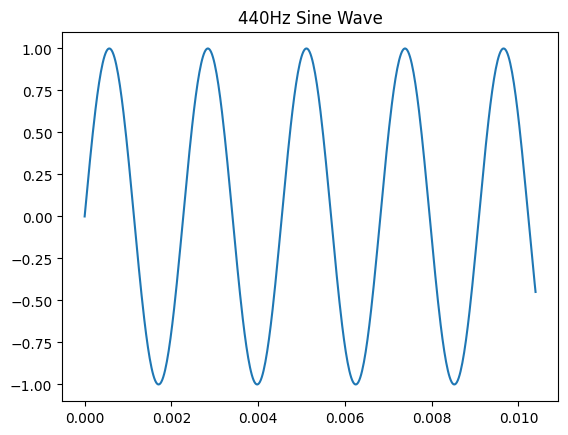

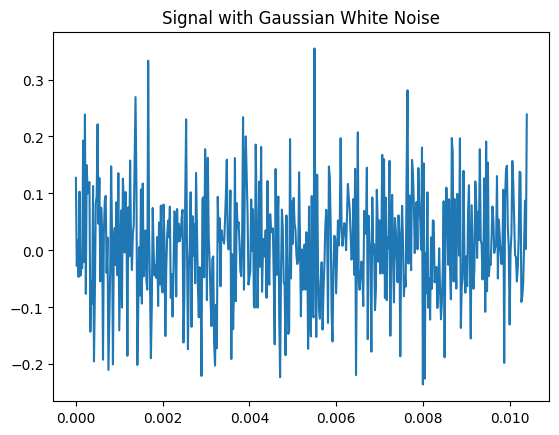

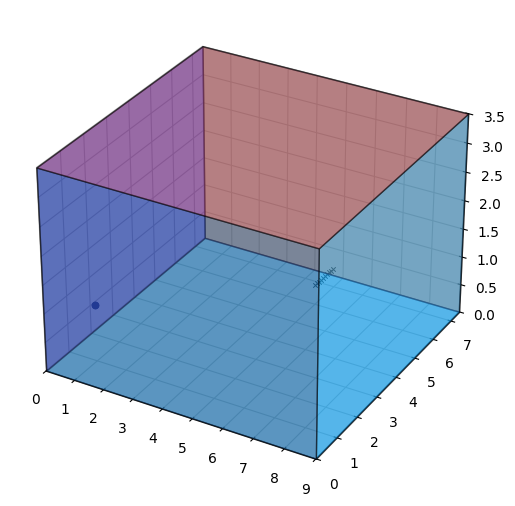

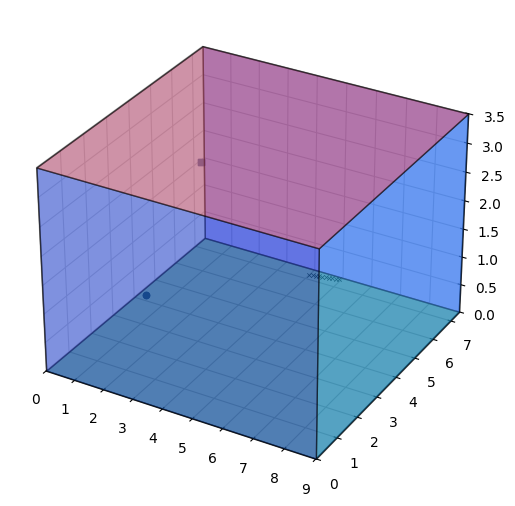

In [ ]:

import pyroomacoustics as pra
import matplotlib.pyplot as plt
from IPython.display import display, Audio,YouTubeVideo
import numpy as np

mic_locs=[]
micarray_ichi=np.linspace(4,5,10,endpoint=False)
print('마이크 어레이의 y위치\n',micarray_ichi,type(micarray_ichi))
for i in micarray_ichi:
    mic_locs.append([6.3,i,1.2])
mic_locs=np.array(mic_locs).T
print('마이크 어레이의 최종 위치\n',mic_locs,type(mic_locs))



def rotate_mic_array(mics, degree):
    # 도(degree)를 라디안(radian)으로 변환
    theta = np.radians(degree)
    mics_center=np.mean(mics,axis=1,keepdims=True)
    mics=mics-mics_center
    # z축 기준 회전 행렬 정의
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])
    
    mics=np.dot(R,mics)+mics_center
    
    # 행렬 곱 연산 (@ 기호는 행렬 곱을 의미합니다)
    # mics가 (3, N) 형태이므로 결과도 (3, N)이 됩니다.
    return mics



# 1. 환경 설정
fs = 48000        # 샘플링 레이트 (1초를 44,100개로 쪼갬)
duration = 1.0    # 1초 동안 재생
f = 440           # 주파수 440Hz

# 2. 시간축 생성 (0초부터 1초까지 fs개만큼 생성)
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# 3. 사인파 생성 (math.sin 대신 np.sin 사용)
# np.sin을 쓰면 t 배열 전체를 한 번에 계산하므로 훨씬 빠릅니다.
sin_signal = np.sin(2 * np.pi * f * t)

# 확인을 위해 아주 짧은 구간(0.01초)만 그려보기
plt.plot(t[:500], sin_signal[:500])
plt.title("440Hz Sine Wave")
plt.show()

# 1. 신호와 같은 길이의 노이즈 생성
# np.random.normal(평균, 표준편차, 샘플수)
mean = 0
std = 0.1  # 표준편차 (이 값이 클수록 노이즈가 커짐)
noise = np.random.normal(mean, std, len(sin_signal))

# 2. 신호에 노이즈 추가
noisy_signal =  noise

# 3. 시각화로 확인
plt.plot(t[:500], noisy_signal[:500])
plt.title("Signal with Gaussian White Noise")
plt.show()

# 残響時間と部屋の寸法
rt60 = 0.5  # seconds
room_dim = [9, 7.5, 3.5]  # meters ここを二次元にすると二次平面の部屋になります
# Sabineの残響式から壁面の平均吸音率と鏡像法での反射回数の上限を決めます
e_absorption, max_order = pra.inverse_sabine(rt60, room_dim)
m = pra.make_materials(
    ceiling=(0.1, 0.05),  # (흡음, 산란)
    floor=(0.2, 0.1),
    east=(0.1, 0.05),
    west=(0.1, 0.05),
    north=(0.1, 0.05),
    south=(0.1, 0.05)
)

room=pra.room.ShoeBox(
    p= room_dim, # 2次元[幅、奥行き], ３次元[幅、奥行き、高さ]
    fs=48000, # サンプリング周波数
    t0=0.0, # シミュレーションの開始時間
    absorption=None,  # 平均壁面吸音率（materialsを設定するときは不要）
    max_order=max_order, # 鏡像法における反射回数の上限 *1
    sigma2_awgn=None, # ガウシアンノイズを乗せる
    sources=None, # 音源データ(リスト)。マイク設定と一緒に使う
    mics=mic_locs,  # マイク座標のリスト（リスト）。音源設定と一緒に使う。
    materials=m, # 建材の設定。詳しくはこの後に書きます。
    temperature=None, # 室温(摂氏)。音速に影響。特に書かないと343m/s
    humidity=None, # 湿度(%)。音速に影響。
    air_absorption=False, # 空気吸収。*2
    ray_tracing=False, # レイトレーシングと鏡像法のハイブリッド利用
    use_rand_ism=False, # よくわからん。音像位置がランダムになる？
    max_rand_disp=0.0 # 上のと一緒に使う
)

#rotated_mics = rotate_mic_array(mic_locs, 45)
#rotated_mics = np.ascontiguousarray(rotated_mics, dtype=np.float64)
#room.add_microphone_array(rotated_mics)
room.add_microphone_array(mic_locs)
room.add_source([1,1,1],signal=sin_signal)
room.simulate()
fig, ax =room.plot(img_order=0)
ax.set_xlim([0, 9]) # 방 크기에 맞춰 조절
ax.set_ylim([0, 7.5])
ax.set_zlim([0, 3.5])
plt.show()

room2 = pra.room.ShoeBox(p=room_dim, fs=48000, max_order=max_order, materials=m)
rotated_mics = rotate_mic_array(mic_locs, 100)
rotated_mics = np.ascontiguousarray(rotated_mics, dtype=np.float64)

room2.add_microphone_array(rotated_mics)
room2.add_source([2,2,1],signal=sin_signal)
room2.add_source([1,6,2],signal=noisy_signal)

room2.simulate()
fig, ax =room2.plot(img_order=0)
ax.set_xlim([0, 9]) # 방 크기에 맞춰 조절
ax.set_ylim([0, 7.5])
ax.set_zlim([0, 3.5])
plt.show()











In [ ]:


# 1. 시뮬레이션된 마이크 수신 신호 가져오기 (각 마이크별로 녹음된 소리)
# shape: (마이크 개수, 샘플 수)
mics_signals = room.mic_array.signals

# 2. 빔포머 객체 생성
# 현재 room에 등록된 마이크 어레이와 fs를 그대로 사용합니다.
beamformer = pra.beamforming.Beamformer(room.mic_array.R, fs=room.fs)

# 3. 빔포머에 수신된 신호 전달
beamformer.signals = mics_signals

# 4. 특정 방향으로 빔포밍 설정 (Delay-and-Sum)
# 음원의 위치 [2, 2, 1]를 알고 있다고 가정하고 그 방향으로 조향(steering)합니다.
source_location = np.array([2, 2, 1])
beamformer.snr = 10.0 # 잡음 대비 신호 비 설정 (선택 사항)
beamformer.beam(source_location)

# 5. 결과물 (빔포밍이 적용된 1채널 소리)
out_signal = beamformer.process()

# 결과 확인 (오디오 재생)
display(Audio(out_signal, rate=fs))

TypeError: Beamformer.steering_vector_2D() missing 2 required positional arguments: 'phi' and 'dist'